# Check Tracking and Trajectory Processing

In [ ]:
# imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from thesis_package.tracking.tracker import MediapipeHandTracker
from thesis_package.tracking.preprocessing import TrajectoryProcessor, LandmarksProcessor
from thesis_package.tracking.visualization import draw_hands, draw_hand_trajectories, draw_raw_vs_processed_trajectories

import mediapipe as mp
print('Mediapipe version:', mp.__version__)

2026-03-19 09:51:33.370645: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Mediapipe version: 0.10.21


In [2]:
FPS = 30
MAX_JUMP_PX = 100
MAX_GAP_SEC = 0.1

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=MAX_JUMP_PX, max_gap_sec=MAX_GAP_SEC)

In [7]:
video_path = "../data/videos/Study1_Videos/2024-01-24_15-52-33.mp4"
df_raw = tracker.track_video(video_path, overwrite=False)
df_processed = processor.process(df_raw, verbose=True)

⏭️ Skipping 2024-01-24_15-52-33 (already tracked). to apply hand tracking again, set overwrite=True
🔄 Trajectory processing pipeline...


In [8]:
df_processed.head()


,frame,hand_label,hand_score,palm_center,frame_diff,segment_id,lm_0_x_smooth,lm_0_y_smooth,lm_5_x_smooth,lm_5_y_smooth,lm_17_x_smooth,lm_17_y_smooth,cx_smooth,cy_smooth
0,2,Right,0.987929,"(211.18032932281494, 286.15731328725815)",NaN,0,226.787939,272.426667,193.681636,266.493394,216.599394,328.016303,209.113075,287.236727
1,3,Right,0.988499,"(212.46991872787476, 286.0425040125847)",1.0,0,208.648152,273.135000,198.615242,266.121182,222.021515,324.389576,208.341586,285.974256
2,4,Right,0.971744,"(193.605854511261, 284.67161625623703)",1.0,0,196.229208,273.225714,204.644866,264.235983,228.444221,320.412199,209.794842,283.856023
3,5,Right,0.997675,"(206.4144992828369, 281.5404671430588)",1.0,0,189.531108,272.698810,211.770506,260.837797,235.867511,316.084173,213.472842,280.882027
4,6,Right,0.975734,"(215.75674057006836, 281.4702335000038)",1.0,0,188.553853,271.554286,219.992165,255.926623,244.291385,311.405498,219.375587,277.052269


Image dimensions: width=1920, height=1080


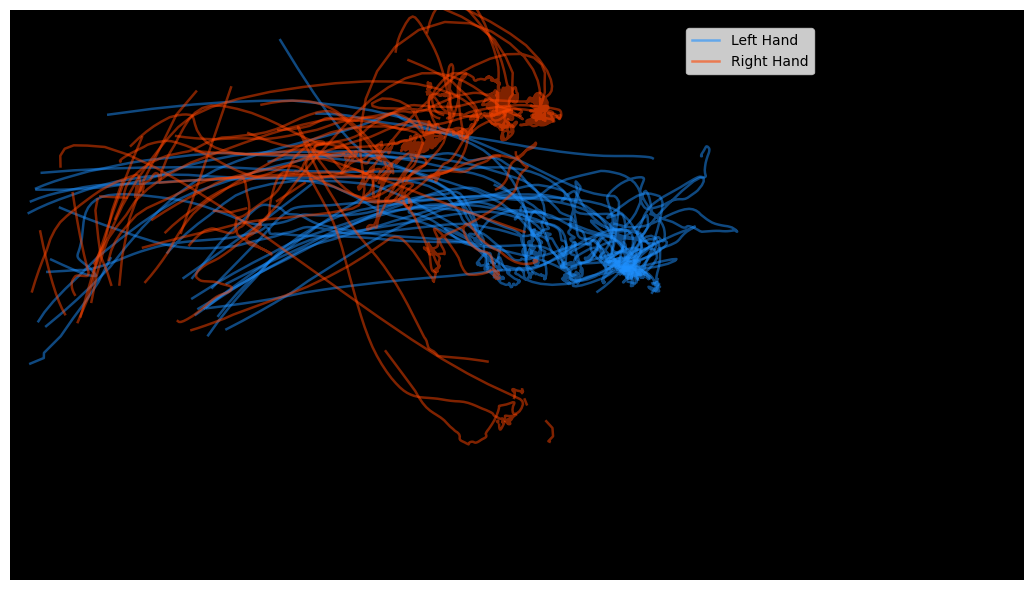

In [9]:
df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
draw_hands(df_hand_left, df_hand_right, title="Processed Hand Trajectories")

#df_hand_left_old = df_processed_old[df_processed_old['hand_label'] == 'Left']
#df_hand_right_old = df_processed_old[df_processed_old['hand_label'] == 'Right']
#draw_hands(df_hand_left_old, df_hand_right_old, title="Old Processed Hand Trajectories")

In [ ]:
draw_raw_vs_processed_trajectories(
    video_path=video_path,
    raw_df=df_raw,
    processed_df=df_processed,
    output_path="data/experiments/short_raw_vs_processed.mp4",
    tail_length=30,
    show_landmarks=("palm_center", "0", "5", "17"),
    show_raw=True,
    show_processed=True,
)

Drawing trajectories for: 2024-01-15_16-17-19


100%|██████████| 9535/9535 [04:13<00:00, 37.65frames/s]

✅ Video saved to: data/experiments/2024-01-15_16-17-19_trajectories_30fps.mp4


'data/experiments/2024-01-15_16-17-19_trajectories_30fps.mp4'

## Process all dataframes

In [4]:
FPS = 30
if FPS == 30:
    max_jump_px = 100
    max_gap_sec = 0.1
else:
    max_jump_px = 100
    max_gap_sec = 0.2

# Just remeber that in final git repo, the videos won't be so I need to add add this list manually somewhere
video_dir = "data/Videos/Study1_videos"
study_videos = [v for v in os.listdir(video_dir) if v.startswith('2024')]

processed_dir = "data/processed/landmark_dataframes2/"
processed_dataframes = [f for f in os.listdir(processed_dir) if f.endswith(f'_{FPS}fps_processed.pkl')]

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=max_jump_px, max_gap_sec=max_gap_sec)

for video in tqdm(study_videos, desc="Processing videos"):
    # skip if already processed
    processed_filename = video.replace(f'.mp4', f'_{FPS}fps_processed.pkl')
    #if processed_filename in processed_dataframes:
    #    print(f"Skipping {video} as it is already processed.")
    #    continue

    df_tracked = tracker.track_video(os.path.join(video_dir, video), overwrite=False)
    processed_df = processor.process(df_tracked)
    processed_df.to_pickle(os.path.join(processed_dir, video.replace(f'.mp4', f'_{FPS}fps_processed.pkl')))

Processing videos:   0%|          | 0/86 [00:00<?, ?it/s]

⏭️ Skipping 2024-01-22_11-22-50 (already processed)


Processing videos:   1%|          | 1/86 [00:19<27:13, 19.22s/it]

⏭️ Skipping 2024-01-24_09-56-13 (already processed)


Processing videos:   2%|▏         | 2/86 [00:36<25:16, 18.05s/it]

...

Processing videos:  98%|█████████▊| 84/86 [26:15<00:24, 12.12s/it]

⏭️ Skipping 2024-01-16_16-03-11 (already processed)


Processing videos:  99%|█████████▉| 85/86 [26:45<00:17, 17.43s/it]

⏭️ Skipping 2024-01-22_11-03-50 (already processed)


Processing videos: 100%|██████████| 86/86 [27:02<00:00, 18.87s/it]


# **RQ1 :** Tracking Quality Reliability Evaluation

1. Tracking Coverage Left and Right with raw tracking data vs processed Data
2. Report fraction of tracked images part of continous segments (>1.5 s) 
3. Report % of interpolated frames

In [ ]:
# paths
raw_data_path = "../data/raw/output_dataframes/"
processed_data_path = "../data/processed/landmark_dataframes/"

raw_files = [f for f in os.listdir(raw_data_path) if '30fps' in f and '2024' in f and f.endswith('.pkl')]
processed_files = [f for f in os.listdir(processed_data_path) if '30fps' in f and '2024' in f and f.endswith('.pkl')]

# remove one surgon's data
raw_files = [f for f in raw_files if '2024-01-17_17-09-36' not in f and '2024-01-17_18-24-28' not in f and '2024-01-17_18-43-42' not in f]
processed_files = [f for f in processed_files if '2024-01-17_17-09-36' not in f and '2024-01-17_18-24-28' not in f and '2024-01-17_18-43-42' not in f]

print(f"Found {len(raw_files)} raw files and {len(processed_files)} processed files.")

In [ ]:
raw_coverages_left = []
raw_coverages_right = []

for filename in tqdm(raw_files):
    # Load raw tracking data
    df_raw = pd.read_pickle(os.path.join(raw_data_path, filename))

    # swaped label on purpose (mediapipe gets it wrong)
    df_raw_right = df_raw[df_raw['hand_label'] == 'Left']
    df_raw_left = df_raw[df_raw['hand_label'] == 'Right']

    right_coverage = df_raw_right['frame'].nunique() / (df_raw['frame'].max() - df_raw['frame'].min() + 1)
    left_coverage = df_raw_left['frame'].nunique() / (df_raw['frame'].max() - df_raw['frame'].min() + 1)

    raw_coverages_right.append(right_coverage)
    raw_coverages_left.append(left_coverage)

In [ ]:
processed_coverages_left = []
processed_coverages_right = []

fracs_continous_traj_left = []
fracs_continous_traj_right = []

perc_interpolated_left_list = []
perc_interpolated_right_list = []

for filename in tqdm(processed_files):
    # Load processed tracking data
    df_processed = pd.read_pickle(os.path.join(processed_data_path, filename))

    df_processed_right = df_processed[df_processed['hand_label'] == 'Right']
    df_processed_left = df_processed[df_processed['hand_label'] == 'Left']

    right_coverage = df_processed_right['frame'].nunique() / (df_processed['frame'].max() - df_processed['frame'].min() + 1)
    left_coverage = df_processed_left['frame'].nunique() / (df_processed['frame'].max() - df_processed['frame'].min() + 1)

    processed_coverages_right.append(right_coverage)
    processed_coverages_left.append(left_coverage)

    # fraction of tracked frames in segments longer than 1.5sec
    seg_lengths_right = df_processed_right.groupby('segment_id').size()
    seg_lengths_left = df_processed_left.groupby('segment_id').size()

    # at least 1.5 sec (45 frames at 30fps)
    frac_right = seg_lengths_right[seg_lengths_right >= 45].sum() / df_processed_right['frame'].nunique()
    frac_left = seg_lengths_left[seg_lengths_left >= 45].sum() / df_processed_left['frame'].nunique()
    fracs_continous_traj_right.append(frac_right)
    fracs_continous_traj_left.append(frac_left)

    # percentage of interpolated frames
    perc_interpolated_right = df_processed_right['hand_score'].isna().sum() / len(df_processed_right)
    perc_interpolated_left = df_processed_left['hand_score'].isna().sum() / len(df_processed_left)
    perc_interpolated_right_list.extend([perc_interpolated_right])
    perc_interpolated_left_list.extend([perc_interpolated_left])

In [ ]:
# raw vs processed coverage
print(f"Raw left hand coverage: {np.mean(raw_coverages_left):.2%} ± {np.std(raw_coverages_left):.2%}")
print(f"Raw right hand coverage: {np.mean(raw_coverages_right):.2%} ± {np.std(raw_coverages_right):.2%}")

print(f"Processed left hand coverage: {np.mean(processed_coverages_left):.2%} ± {np.std(processed_coverages_left):.2%}")
print(f"Processed right hand coverage: {np.mean(processed_coverages_right):.2%} ± {np.std(processed_coverages_right):.2%}")

In [ ]:
# number of interpolated frames
print(f"Percentage of interpolated frames (left hand): {np.mean(perc_interpolated_left_list):.4f} ± {np.std(perc_interpolated_left_list):.4f}")
print(f"Percentage of interpolated frames (right hand): {np.mean(perc_interpolated_right_list):.4f} ± {np.std(perc_interpolated_right_list):.4f}")

In [ ]:
# median gap length distribution
print("Fraction of continous trajcectories (frames belonging to segments longer than 1.5 sec / total_tracked frames):")
print(f"Left hand):\n {np.mean(fracs_continous_traj_left):.2%} ± {np.std(fracs_continous_traj_left):.2%}")
print(f"Right hand):\n {np.mean(fracs_continous_traj_right):.2%} ± {np.std(fracs_continous_traj_right):.2%}")

# For Thesis Figures

In [10]:
video_path = "../data/videos/Study1_Videos/short_final_img.mp4"
out_path = "../data/experiments/short_final_img_tracking_overlay.mp4"

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=MAX_JUMP_PX, max_gap_sec=MAX_GAP_SEC)

df_raw = tracker.track_video(video_path, overwrite=False)
#df_processed = processor.process(df_raw)

⏭️ Skipping short_final_img (already tracked). to apply hand tracking again, set overwrite=True


In [138]:
overlay_path = tracker.render_tracking_overlay_video(
    video_path=video_path,
    tracking_df=df_raw,
    output_path=out_path,
    show_label=True,
    show_score=True,
    show_frame_idx=False,
    overwrite=True
)

print(overlay_path)

▶️ Rendering tracking overlay video...
✅ Video saved successfully: data/experiments/short_final_img_tracking_overlay.mp4
data/experiments/short_final_img_tracking_overlay.mp4


In [12]:
video_path = "data/videos/Study1_Videos/2024-01-24_15-52-33.mp4"

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=MAX_JUMP_PX, max_gap_sec=MAX_GAP_SEC)

raw_df = tracker.track_video(video_path, overwrite=False)
df_processed = processor.process(raw_df, verbose=True)

⏭️ Skipping 2024-01-24_15-52-33 (already tracked). to apply hand tracking again, set overwrite=True


Image dimensions: width=1920, height=1077


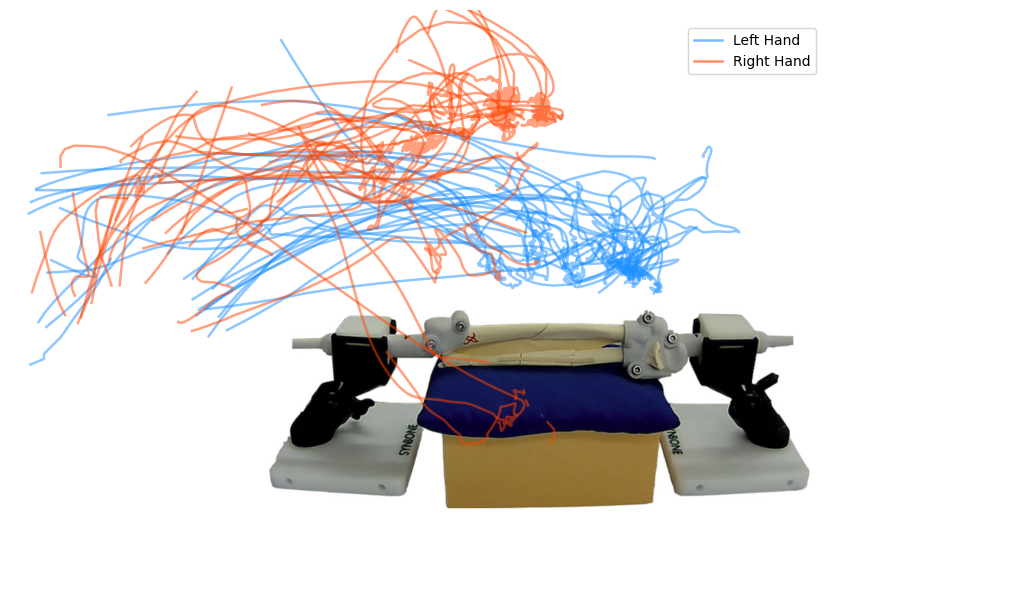

In [14]:

df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
draw_hands(df_hand_left, df_hand_right, title="Processed Hand Trajectories", background="../data/experiments/background2.png")